# Continual Gait Identification — Unified Security Evaluation

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## Overview

This notebook provides a **structured, end-to-end evaluation** of six continual learning models under three privacy attacks. The central research question is:

> *Which model achieves the best trade-off between continual learning accuracy and resistance to privacy attacks?*

### Models evaluated

| # | Model | Description | Anti-forgetting | Privacy mechanism |
|---|---|---|---|---|
| 1 | **Std 0%** | Baseline sequential fine-tuning | None | None |
| 2 | **Std 15%** | Fine-tuning with 15% raw replay | Experience replay | None |
| 3 | **CDML** | Code Division Modulation Layers | Sequence modulation | Per-task key |
| 4 | **CDML+KD** | CDML + focal knowledge distillation | Distillation + key | Per-task key |
| 5 | **WGR-CDML** | CDML + wavelet generative replay | Synthetic replay + key | Per-task key + no raw data |
| 6 | **LiDER** | CDML + Lipschitz-driven replay | Spectral regularisation + key | Per-task key |

### Attacks evaluated

| # | Attack | Type | Goal |
|---|---|---|---|
| A | **Identity Inference Attack (IIA)** | Black-box, score-based | Was this specific person enrolled? |
| B | **Feature Space Inference** | White-box, geometry-based | Can embeddings be used to identify users? |
| C | **Backdoor / Trojan Attack** | Poisoning | Does a trigger reliably authenticate an attacker? |

### Threat model for CDML models

All CDML-based models are evaluated under two attacker levels:
- **No-seed** (realistic): attacker zeros out the modulation sequence — the only information available from black-box access
- **Oracle** (upper bound): attacker knows the correct seed — measures the maximum possible leakage

---

## 0. Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — using DWT decomposition')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

PyWavelets available — using DWT decomposition
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

All hyperparameters are defined here. Set `EPOCHS = 400` for paper-accurate results.

In [9]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50   # 100 = fast iteration | 400 = paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
STD_REPLAY_FRAC  = 0.15   # Std 15% model

# CDML+KD (focal distillation)
KD_LAMBDA        = 0.001
KD_ALPHA         = 0.0    # focal: 0 = only penalise correct-sample divergence
KD_BETA          = 1.0
KD_MEMORY_FRAC   = 0.20

# WGR-CDML (Wavelet Generative Replay)
WGR_WAVELET      = 'db4'
WGR_LEVEL        = 3
WGR_N_SYNTH      = 30
WGR_JITTER_STD   = 0.05

# LiDER (Lipschitz-Driven Experience Replay)
LIDER_REPLAY_FRAC = 0.10
LIDER_WEIGHT      = 0.01
LIDER_KAPPA       = 2.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_AGGREGATION  = 'mean'

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K            = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
BACKDOOR_TARGET_IDX  = 90    # Task 4 subject (never forgotten)
BACKDOOR_POISON_FRAC = 0.15
BACKDOOR_TRIGGER_AMP = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH  = 2     # acc_z channel

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading

In [10]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions

In [11]:
# ── Shared backbone ───────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

# ── CDML layer and model ──────────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def embed_raw(self, x):        return self.backbone.embed(x)
    def embed_modulated(self, x):  return self.cdml(self.backbone.embed(x))
    def forward(self, x):          return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)
    def zero_sequence(self):
        """Attacker without seed: zeroes all embeddings."""
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

# ── Shared utilities ──────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t

def make_replay_subset(dataset, frac, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n   = len(dataset)
    k   = max(1, int(n * frac))
    idx = rng.choice(n, k, replace=False).tolist()
    Xs, ys = zip(*[dataset[i] for i in idx])
    return TensorDataset(torch.stack(Xs), torch.stack(ys))

print(f'GaitCNN params: {sum(p.numel() for p in GaitCNN(N_CHANNELS,N_CLASSES_TOTAL,EMBED_DIM).parameters()):,}')
print('Model classes defined.')

GaitCNN params: 227,222
Model classes defined.


## 4. WGR and LiDER-specific components

In [12]:
# ── Wavelet utilities (WGR-CDML) ──────────────────────────────────────────────
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1), \
           np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1)

class WaveletReplayBuffer:
    """Stores per-class DWT statistics, generates synthetic gait windows on demand."""
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng = np.random.default_rng(seed)
        self._tasks = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            class_stats, detail_stats = {}, []
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0)+1e-6}
            for lv in range(1, self.level+1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0)+1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {int(cls): {'mu': X_low[y_np==cls].reshape(sum(y_np==cls),-1).mean(0),
                                       'sigma': X_low[y_np==cls].reshape(sum(y_np==cls),-1).std(0)+1e-6}
                           for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0)+1e-6}]
            coeff_lens = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = recon[:T] if len(recon) >= T else np.pad(recon.astype(np.float32), (0, T-len(recon)))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T//4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T: xh = np.pad(xh, ((0,0),(0,T-xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        parts = [self.synthesize_task(i) for i in range(len(self._tasks))]
        return ConcatDataset(parts)

# ── LiDER spectral norm utility ───────────────────────────────────────────────
def spectral_norm_approx(W, n_iter=3):
    W2d = W.view(W.shape[0], -1)
    if min(W2d.shape) == 0: return torch.tensor(0.0, device=W.device)
    u = F.normalize(torch.randn(W2d.shape[0], 1, device=W.device), dim=0)
    v = F.normalize(torch.randn(W2d.shape[1], 1, device=W.device), dim=0)
    for _ in range(n_iter):
        v = F.normalize(W2d.t() @ u, dim=0)
        u = F.normalize(W2d @ v,     dim=0)
    return (u.t() @ W2d @ v).squeeze().abs()

def lider_penalty(model, kappa=LIDER_KAPPA):
    """L_LiDER = Σ_l max(0, σ(W_l) − κ)²   (Bonicelli et al. NeurIPS 2022)"""
    total    = torch.tensor(0.0, device=next(model.parameters()).device)
    backbone = model.backbone if hasattr(model, 'backbone') else model
    for m in backbone.modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            total = total + F.relu(spectral_norm_approx(m.weight) - kappa) ** 2
    return total

# ── KD distillation loss (CDML+KD) ────────────────────────────────────────────
def focal_distill_loss(logits_new, logits_old, y_true, alpha, beta):
    """L_KD = (α + β·I[ŷ_old=y]) · ‖f_new−f_old‖²   (Angioni et al. 2025)"""
    l2      = ((logits_new - logits_old)**2).sum(dim=1)
    correct = (logits_old.argmax(1) == y_true).float()
    return ((alpha + beta * correct) * l2).mean()

print('All model components defined.')

All model components defined.


## 5. Training — all six models

Each model is trained sequentially on Tasks 1→4. After each task a snapshot is saved.

In [13]:
def _run_epoch(model, loader, optimizer, criterion, device,
               is_cdml=False, task_name=None, seed_k=None,
               kd_old=None, buf_iter=None, buf_loader=None,
               lider_w=0.0, kappa=2.0):
    model.train()
    if is_cdml and task_name: model.set_task_sequence(task_name, seed_k)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        # KD term
        if kd_old is not None and buf_iter is not None:
            try:    Xp, yp = next(buf_iter)
            except: buf_iter = iter(buf_loader); Xp, yp = next(buf_iter)
            Xp, yp = Xp.to(device), yp.to(device)
            with torch.no_grad(): lo = kd_old(Xp)
            loss = loss + KD_LAMBDA * focal_distill_loss(model(Xp), lo, yp, KD_ALPHA, KD_BETA)
        # LiDER term
        if lider_w > 0:
            loss = loss + lider_w * lider_penalty(model, kappa)
        loss.backward()
        optimizer.step()
    return buf_iter


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device, is_cdml):
    for ei, et in enumerate(task_names[:step_idx+1]):
        if is_cdml: model.set_task_sequence(et, model.seeds[et])
        tl  = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)


def train_std(task_data, task_names, device, epochs, lr_init, lr_decay,
               batch_size, replay_frac=0.0, label='Std', verbose_every=25):
    """Std or Std+replay training."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        if replay_frac > 0:
            replay_buf.append(make_replay_subset(task_data[task_name]['train'], replay_frac))
    return model, acc_matrix


def train_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                batch_size, label='CDML', verbose_every=25):
    """Plain CDML — no replay."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  (seed={seed_k})')
        loader    = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_cdml_kd(task_data, task_names, device, epochs, lr_init, lr_decay,
                   batch_size, label='CDML+KD', verbose_every=25):
    """CDML + focal knowledge distillation (Phase 5)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    old_model  = None
    mem_buf    = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        loader     = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        buf_loader = DataLoader(ConcatDataset(mem_buf), batch_size=batch_size,
                                shuffle=True) if mem_buf else None
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            buf_iter = iter(buf_loader) if buf_loader else None
            buf_iter = _run_epoch(model, loader, optimizer, criterion, device,
                                  is_cdml=True, task_name=task_name, seed_k=seed_k,
                                  kd_old=old_model, buf_iter=buf_iter, buf_loader=buf_loader)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        old_model = deepcopy(model); old_model.eval()
        for p in old_model.parameters(): p.requires_grad_(False)
        mem_buf.append(make_replay_subset(task_data[task_name]['train'], KD_MEMORY_FRAC,
                                          seed=RANDOM_SEED+step_idx))
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_wgr_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='WGR-CDML', verbose_every=25):
    """WGR-CDML: CDML + wavelet generative replay (no raw data stored)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')
        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)
    return model, acc_matrix


def train_lider(task_data, task_names, device, epochs, lr_init, lr_decay,
                 batch_size, label='LiDER', verbose_every=25):
    """LiDER: CDML + 10% experience replay + Lipschitz spectral penalty."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        lider_w   = LIDER_WEIGHT if step_idx > 0 else 0.0
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k,
                       lider_w=lider_w, kappa=LIDER_KAPPA)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        replay_buf.append(make_replay_subset(task_data[task_name]['train'], LIDER_REPLAY_FRAC))
    return model, acc_matrix

print('All training functions defined.')

All training functions defined.


In [14]:
print('='*60 + '\nTraining all 6 models\n' + '='*60)

model_std0,  acc_std0  = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0,         label='Std 0%')
print()
model_std15, acc_std15 = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=STD_REPLAY_FRAC, label='Std 15%')
print()
model_cdml,  acc_cdml  = train_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_kd,    acc_kd    = train_cdml_kd(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_wgr,   acc_wgr   = train_wgr_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_lider, acc_lider = train_lider(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)

# Registry — used by all attack cells below
# Each entry: (label, model, acc_matrix, is_cdml, color)
MODEL_REGISTRY = [
    ('Std 0%',    model_std0,  acc_std0,  False, '#E74C3C'),
    ('Std 15%',   model_std15, acc_std15, False, '#E67E22'),
    ('CDML',      model_cdml,  acc_cdml,  True,  '#3498DB'),
    ('CDML+KD',   model_kd,    acc_kd,    True,  '#2980B9'),
    ('WGR-CDML',  model_wgr,   acc_wgr,   True,  '#27AE60'),
    ('LiDER',     model_lider, acc_lider, True,  '#8E44AD'),
]

print('\n── Final accuracy (after Task 4) ──')
print(f'  {"Model":<12}  T1      T2      T3      T4      Avg')
print('  ' + '─'*55)
for label, _, mat, *_ in MODEL_REGISTRY:
    vals = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg  = np.nanmean(mat[-1,:]) * 100
    print(f'  {label:<12}  ' + '  '.join([f'{v:5.1f}%' for v in vals]) + f'  {avg:5.1f}%')

Training all 6 models
[Std 0%] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[Std 0%] Step 2: Task 2
  Epoch   1/50  val=0.934
  Epoch  25/50  val=0.979
  Epoch  50/50  val=0.982
  → T1:0.3%  T2:93.6%
[Std 0%] Step 3: Task 3
  Epoch   1/50  val=0.936
  Epoch  25/50  val=0.975
  Epoch  50/50  val=0.975
  → T1:0.0%  T2:0.0%  T3:92.8%
[Std 0%] Step 4: Task 4
  Epoch   1/50  val=0.961
  Epoch  25/50  val=0.982
  Epoch  50/50  val=0.980
  → T1:0.0%  T2:0.0%  T3:0.0%  T4:98.0%

[Std 15%] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[Std 15%] Step 2: Task 2
  Epoch   1/50  val=0.919
  Epoch  25/50  val=0.969
  Epoch  50/50  val=0.980
  → T1:86.1%  T2:93.8%
[Std 15%] Step 3: Task 3
  Epoch   1/50  val=0.950
  Epoch  25/50  val=0.975
  Epoch  50/50  val=0.977
  → T1:85.2%  T2:86.4%  T3:90.7%
[Std 15%] Step 4: Task 4
  Epoch   1/50  val=0.962
  Epoch  25/50  val=0.981
  Epoch 

## 6. Accuracy visualisation — forgetting matrices and curves

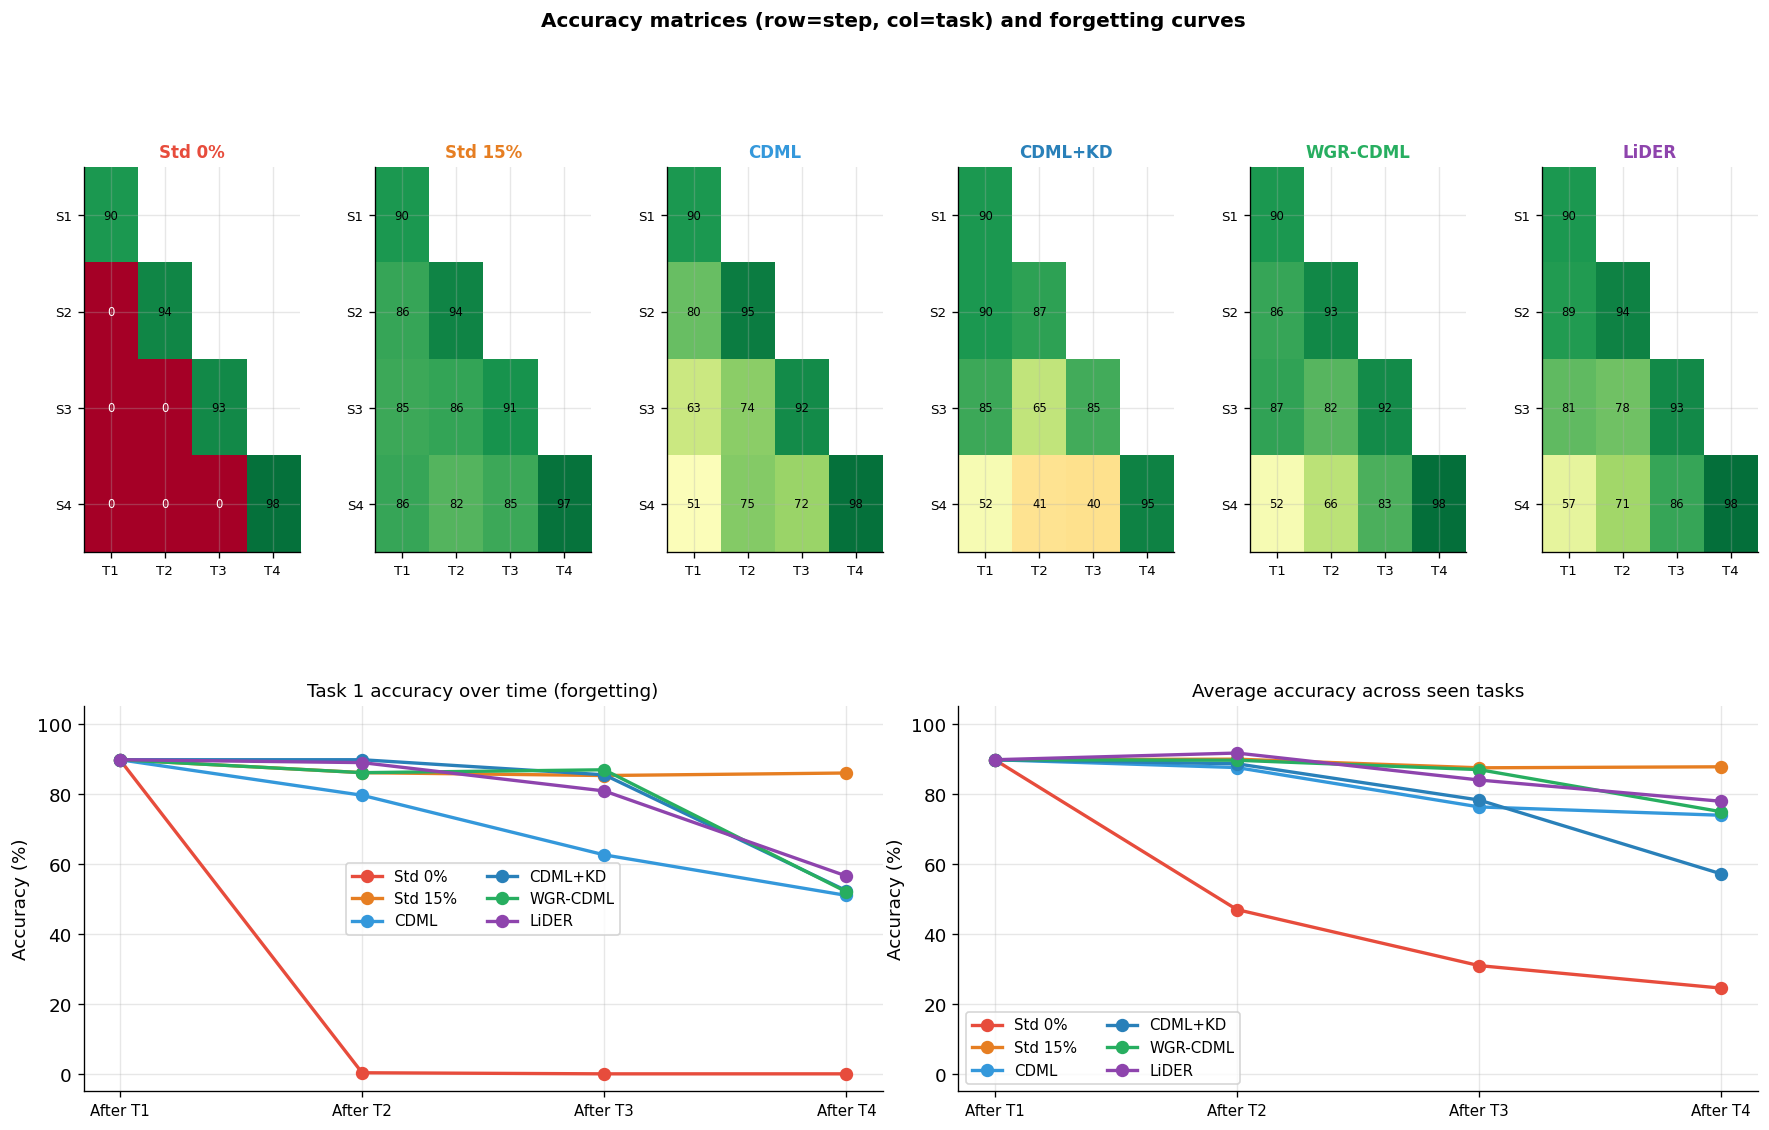

In [15]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.35)

# Row 0: accuracy matrices
for col, (label, _, mat, _, color) in enumerate(MODEL_REGISTRY):
    ax = fig.add_subplot(gs[0, col])
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(n_tasks)); ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)], fontsize=8)
    ax.set_yticklabels([f'S{i+1}' for i in range(n_tasks)], fontsize=8)
    ax.set_title(label, color=color, fontsize=10, fontweight='bold')
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i,j]):
                v = mat[i,j]*100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=7, color='k' if v>20 else 'w')

# Row 1: Task 1 retention and average accuracy curves
ax_t1  = fig.add_subplot(gs[1, :3])
ax_avg = fig.add_subplot(gs[1, 3:])
steps  = list(range(1, n_tasks+1))

for label, _, mat, _, color in MODEL_REGISTRY:
    t1_vals  = [mat[s,0]*100 for s in range(n_tasks) if not np.isnan(mat[s,0])]
    avg_vals = [np.nanmean(mat[s,:s+1])*100 for s in range(n_tasks)]
    ax_t1.plot(steps[:len(t1_vals)], t1_vals, 'o-', color=color, lw=2, ms=7, label=label)
    ax_avg.plot(steps, avg_vals, 'o-', color=color, lw=2, ms=7, label=label)

for ax, title in [(ax_t1, 'Task 1 accuracy over time (forgetting)'),
                   (ax_avg, 'Average accuracy across seen tasks')]:
    ax.set_xticks(steps)
    ax.set_xticklabels([f'After T{s}' for s in steps], fontsize=9)
    ax.set_ylim(-5, 105); ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, ncol=2)

fig.suptitle('Accuracy matrices (row=step, col=task) and forgetting curves',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('fig_accuracy_overview.png', bbox_inches='tight')
plt.show()

---
## Attack A — Identity Inference Attack (IIA)

**Goal:** Was this specific person's gait data used to train the model?

**Protocol:** For each enrolled subject, aggregate CE loss scores across N test windows. Compare against non-enrolled subjects from other tasks. Compute AUC / EER.

**Score:** `score(s) = -mean_CE(model(x), s)` — lower CE loss means the model recognises subject s.

**CDML attacker modes:** no-seed (realistic) and oracle (upper bound).

In [16]:
@torch.no_grad()
def iia_score(model, X_windows, subj_idx, device, aggregation='mean'):
    model.eval()
    X_windows = X_windows.to(device)
    y_true    = torch.full((len(X_windows),), subj_idx, dtype=torch.long, device=device)
    losses    = nn.CrossEntropyLoss(reduction='none')(model(X_windows), y_true).cpu().float().numpy()
    return float((-losses).mean() if aggregation == 'mean' else (-losses).max())


def run_iia(model, task_data, task_names, device, is_cdml=False,
             cdml_mode='none', n_queries=IIA_N_QUERIES):
    """
    cdml_mode: 'none' | 'oracle' | 'no_seed'
    Returns per-task {auc, eer, member_scores, nonmember_scores}
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):
        lo, hi    = TASK_SPLITS[task_name]
        task_subj = [label_to_idx[s] for s in range(lo, hi+1) if s in label_to_idx]
        test_ds   = task_data[task_name]['test']

        if cdml_mode == 'oracle' and is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        elif cdml_mode == 'no_seed' and is_cdml:
            model.zero_sequence()

        member_scores = []
        for subj_idx in task_subj:
            X_mem = torch.stack([test_ds[i][0] for i in range(len(test_ds))
                                  if test_ds[i][1].item() == subj_idx])
            if len(X_mem) == 0: continue
            member_scores.append(iia_score(model, X_mem[:n_queries], subj_idx, device))

        nonmember_scores = []
        for other_task in [t for t in task_names if t != task_name]:
            other_lo, other_hi = TASK_SPLITS[other_task]
            other_subjs = [label_to_idx[s] for s in range(other_lo, other_hi+1)
                           if s in label_to_idx]
            other_ds = task_data[other_task]['test']
            for subj_idx in other_subjs:
                # Restore sequence for each non-member query
                if cdml_mode == 'oracle' and is_cdml:
                    model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
                elif cdml_mode == 'no_seed' and is_cdml:
                    model.zero_sequence()
                X_nm = torch.stack([other_ds[i][0] for i in range(len(other_ds))
                                     if other_ds[i][1].item() == subj_idx])
                if len(X_nm) == 0: continue
                nonmember_scores.append(iia_score(model, X_nm[:n_queries], subj_idx, device))

        m_arr  = np.array(member_scores)
        nm_arr = np.array(nonmember_scores[:len(m_arr)])  # balance
        scores = np.concatenate([m_arr, nm_arr])
        labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr         = 1 - tpr
        eer         = float(np.mean([fpr[np.nanargmin(np.abs(fpr-fnr))],
                                     fnr[np.nanargmin(np.abs(fpr-fnr))]]))
        results[task_name] = {'auc': roc_auc, 'eer': eer,
                               'fpr': fpr, 'tpr': tpr,
                               'm_scores': m_arr, 'nm_scores': nm_arr}
    return results


print('Running IIA on all models...')
iia_results = {}

for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if not is_cdml:
        print(f'  {label}...')
        iia_results[label] = run_iia(model, task_data, task_names, DEVICE,
                                      is_cdml=False, cdml_mode='none')
    else:
        print(f'  {label} (no-seed)...')
        iia_results[f'{label} (no-seed)'] = run_iia(model, task_data, task_names, DEVICE,
                                                      is_cdml=True, cdml_mode='no_seed')
        print(f'  {label} (oracle)...')
        iia_results[f'{label} (oracle)'] = run_iia(model, task_data, task_names, DEVICE,
                                                    is_cdml=True, cdml_mode='oracle')

# Restore correct sequences after IIA
for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if is_cdml:
        model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('IIA complete.')

Running IIA on all models...
  Std 0%...
  Std 15%...
  CDML (no-seed)...
  CDML (oracle)...
  CDML+KD (no-seed)...
  CDML+KD (oracle)...
  WGR-CDML (no-seed)...
  WGR-CDML (oracle)...
  LiDER (no-seed)...
  LiDER (oracle)...
IIA complete.


── IIA Results: AUC per task (50% = random guess) ──
  Model                      |   Task 1 |   Task 2 |   Task 3 |   Task 4 | Avg
  ────────────────────────────────────────────────────────────────────────────────
  Std 0%                     |    41.7% |    58.3% |    66.1% |    99.6% |  66.4%
  Std 15%                    |    64.6% |    35.4% |    45.9% |    58.4% |  51.1%
  CDML (no-seed)             |    42.7% |    57.3% |    50.0% |    60.7% |  52.7%
  CDML (oracle)              |    96.9% |    99.9% |    99.9% |   100.0% |  99.2%
  CDML+KD (no-seed)          |    28.4% |    71.6% |    56.1% |    52.9% |  52.3%
  CDML+KD (oracle)           |    93.9% |    30.4% |    13.8% |    30.4% |  42.1%
  WGR-CDML (no-seed)         |    46.0% |    54.0% |    39.3% |    32.4% |  42.9%
  WGR-CDML (oracle)          |    96.0% |    60.0% |    79.6% |    88.0% |  80.9%
  LiDER (no-seed)            |    46.1% |    53.9% |    46.3% |    42.5% |  47.2%
  LiDER (oracle)             |    93.1% |    50

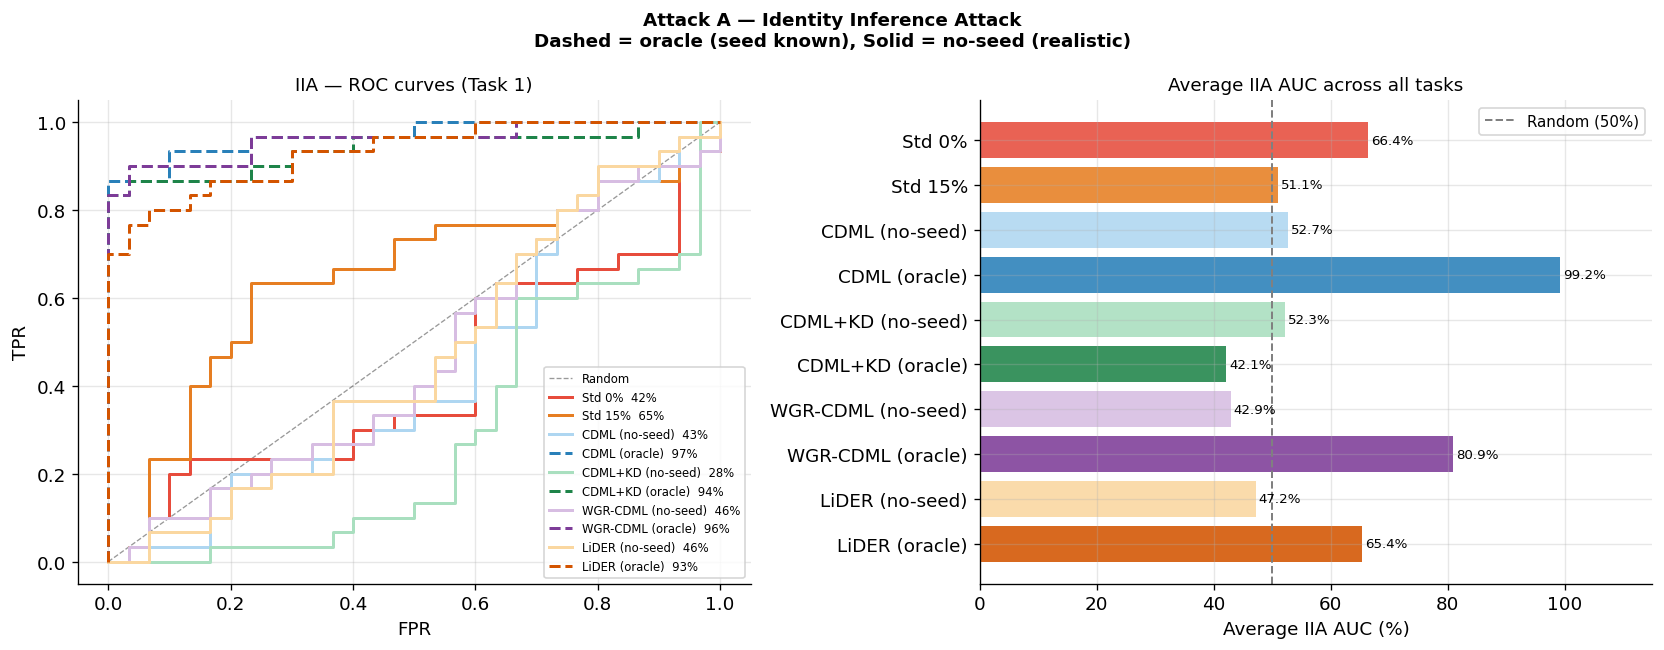

In [17]:
# ── IIA results table ─────────────────────────────────────────────────────────
print('── IIA Results: AUC per task (50% = random guess) ──')
header = f'  {"Model":<26} | ' + ' | '.join([f'{t:>8}' for t in task_names]) + ' | Avg'
print(header); print('  ' + '─'*80)
for key, res in iia_results.items():
    aucs = [res[t]['auc']*100 for t in task_names]
    print(f'  {key:<26} | ' + ' | '.join([f'{a:>7.1f}%' for a in aucs])
          + f' | {np.mean(aucs):>5.1f}%')

# ── IIA visualisation ────────────────────────────────────────────────────────
FOCUS_TASK = 'Task 1'
iia_colors = {
    'Std 0%':           '#E74C3C', 'Std 15%':            '#E67E22',
    'CDML (no-seed)':   '#AED6F1', 'CDML (oracle)':      '#2980B9',
    'CDML+KD (no-seed)':'#A9DFBF', 'CDML+KD (oracle)':   '#1E8449',
    'WGR-CDML (no-seed)':'#D7BDE2','WGR-CDML (oracle)':  '#7D3C98',
    'LiDER (no-seed)':  '#FAD7A0', 'LiDER (oracle)':     '#D35400',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC curves for FOCUS_TASK
ax = axes[0]
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4,label='Random')
for key, res in iia_results.items():
    if key in iia_colors:
        fpr, tpr = res[FOCUS_TASK]['fpr'], res[FOCUS_TASK]['tpr']
        roc_a    = res[FOCUS_TASK]['auc']
        ls = '--' if 'oracle' in key else '-'
        ax.plot(fpr, tpr, color=iia_colors[key], lw=1.8, ls=ls,
                label=f'{key}  {roc_a*100:.0f}%')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'IIA — ROC curves ({FOCUS_TASK})', fontsize=11)
ax.legend(fontsize=7, loc='lower right', ncol=1)

# Average AUC bar chart
ax2 = axes[1]
keys    = list(iia_results.keys())
avg_aucs= [np.mean([iia_results[k][t]['auc']*100 for t in task_names]) for k in keys]
bar_colors = [iia_colors.get(k, '#888') for k in keys]
bars = ax2.barh(keys[::-1], avg_aucs[::-1], color=bar_colors[::-1], alpha=0.88)
ax2.axvline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
for bar in bars:
    ax2.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=8)
ax2.set_xlabel('Average IIA AUC (%)')
ax2.set_title('Average IIA AUC across all tasks', fontsize=11)
ax2.set_xlim(0, 115)
ax2.legend(fontsize=9)

plt.suptitle('Attack A — Identity Inference Attack\n'
             'Dashed = oracle (seed known), Solid = no-seed (realistic)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_iia_results.png', bbox_inches='tight')
plt.show()

---
## Attack B — Feature Space Inference (Embedding Geometry Probe)

**Goal:** Can an attacker reconstruct user identities from the model's embedding space?

**Protocol:** Extract embeddings from the trained model. Fit a k-NN classifier on training embeddings. Evaluate identity attribution accuracy on test embeddings.

**Key question:** Does CDML's sequence scrambling disrupt the embedding geometry enough to prevent identity attribution?

- **Raw h** (Std models, white-box CDML): backbone embedding before any modulation
- **No-seed** (CDML models, realistic attacker): zeroed sequence → all-zero embeddings → random predictions
- **Oracle** (CDML models): correct sequence → scrambled but recoverable geometry

In [18]:
@torch.no_grad()
def extract_embeddings(model, dataset, device, seq_mode='raw', k_tasks=None):
    """
    seq_mode:
      'raw'     -> backbone h (before CDML) — used for Std models
      'oracle'  -> scrambled m = s_k ⊙ h, correct sequence set before call
      'no_seed' -> zeroed sequence (attacker without seed)
    """
    model.eval()
    if seq_mode == 'no_seed' and hasattr(model, 'zero_sequence'):
        model.zero_sequence()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    all_h, all_y = [], []
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        if seq_mode == 'raw':
            h = model.backbone.embed(X_b) if hasattr(model, 'backbone') else model.embed(X_b)
        else:
            h = model.embed_modulated(X_b) if hasattr(model, 'embed_modulated') else model.embed(X_b)
        all_h.append(h.cpu().float().numpy())
        all_y.append(y_b.numpy())
    return np.concatenate(all_h), np.concatenate(all_y)


def run_feature_probe(model, task_data, task_names, device,
                       is_cdml=False, seq_mode='raw', k=KNN_K):
    """
    Fit k-NN on training embeddings, evaluate on test embeddings.
    Returns {task_name: {top1_acc, mean_conf}}
    """
    # Build training embeddings
    if seq_mode == 'oracle' and is_cdml:
        tr_h_list, tr_y_list = [], []
        for t_idx, t_name in enumerate(task_names):
            model.set_task_sequence(t_name, CDML_SEED_BASE + t_idx)
            h, y = extract_embeddings(model, task_data[t_name]['train'], device, 'oracle')
            tr_h_list.append(h); tr_y_list.append(y)
        tr_h = np.concatenate(tr_h_list); tr_y = np.concatenate(tr_y_list)
    else:
        all_tr = ConcatDataset([task_data[t]['train'] for t in task_names])
        tr_h, tr_y = extract_embeddings(model, all_tr, device, seq_mode)

    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(tr_h, tr_y)

    results = {}
    for t_idx, task_name in enumerate(task_names):
        if seq_mode == 'oracle' and is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        te_h, te_y = extract_embeddings(model, task_data[task_name]['test'], device, seq_mode)
        preds = knn.predict(te_h)
        top1  = (preds == te_y).mean()
        conf  = knn.predict_proba(te_h).max(axis=1).mean()
        results[task_name] = {'top1_acc': top1, 'mean_conf': conf}
    return results


print('Running Feature Space Inference on all models...')
probe_results = {}
chance = 1.0 / 30   # 30 subjects per task, random baseline

for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if not is_cdml:
        print(f'  {label} (raw h)...')
        probe_results[label] = run_feature_probe(model, task_data, task_names, DEVICE,
                                                  is_cdml=False, seq_mode='raw')
    else:
        print(f'  {label} (no-seed)...')
        probe_results[f'{label} (no-seed)'] = run_feature_probe(
            model, task_data, task_names, DEVICE, is_cdml=True, seq_mode='no_seed')
        print(f'  {label} (oracle)...')
        probe_results[f'{label} (oracle)'] = run_feature_probe(
            model, task_data, task_names, DEVICE, is_cdml=True, seq_mode='oracle')

# Restore sequences
for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if is_cdml: model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('\n── Feature Probe: average top-1 identity attribution accuracy ──')
print(f'  Chance level (random over 30 subjects): {chance*100:.1f}%')
for key, res in probe_results.items():
    avg = np.mean([res[t]['top1_acc'] for t in task_names]) * 100
    bar = '█' * int(avg / 2)
    print(f'  {key:<28}: {avg:5.1f}%  {bar}')

Running Feature Space Inference on all models...
  Std 0% (raw h)...
  Std 15% (raw h)...
  CDML (no-seed)...
  CDML (oracle)...
  CDML+KD (no-seed)...
  CDML+KD (oracle)...
  WGR-CDML (no-seed)...
  WGR-CDML (oracle)...
  LiDER (no-seed)...
  LiDER (oracle)...

── Feature Probe: average top-1 identity attribution accuracy ──
  Chance level (random over 30 subjects): 3.3%
  Std 0%                      :  87.7%  ███████████████████████████████████████████
  Std 15%                     :  90.3%  █████████████████████████████████████████████
  CDML (no-seed)              :   1.0%  
  CDML (oracle)               :  93.6%  ██████████████████████████████████████████████
  CDML+KD (no-seed)           :   1.0%  
  CDML+KD (oracle)            :  93.6%  ██████████████████████████████████████████████
  WGR-CDML (no-seed)          :   1.0%  
  WGR-CDML (oracle)           :  94.1%  ███████████████████████████████████████████████
  LiDER (no-seed)             :   1.0%  
  LiDER (oracle)             

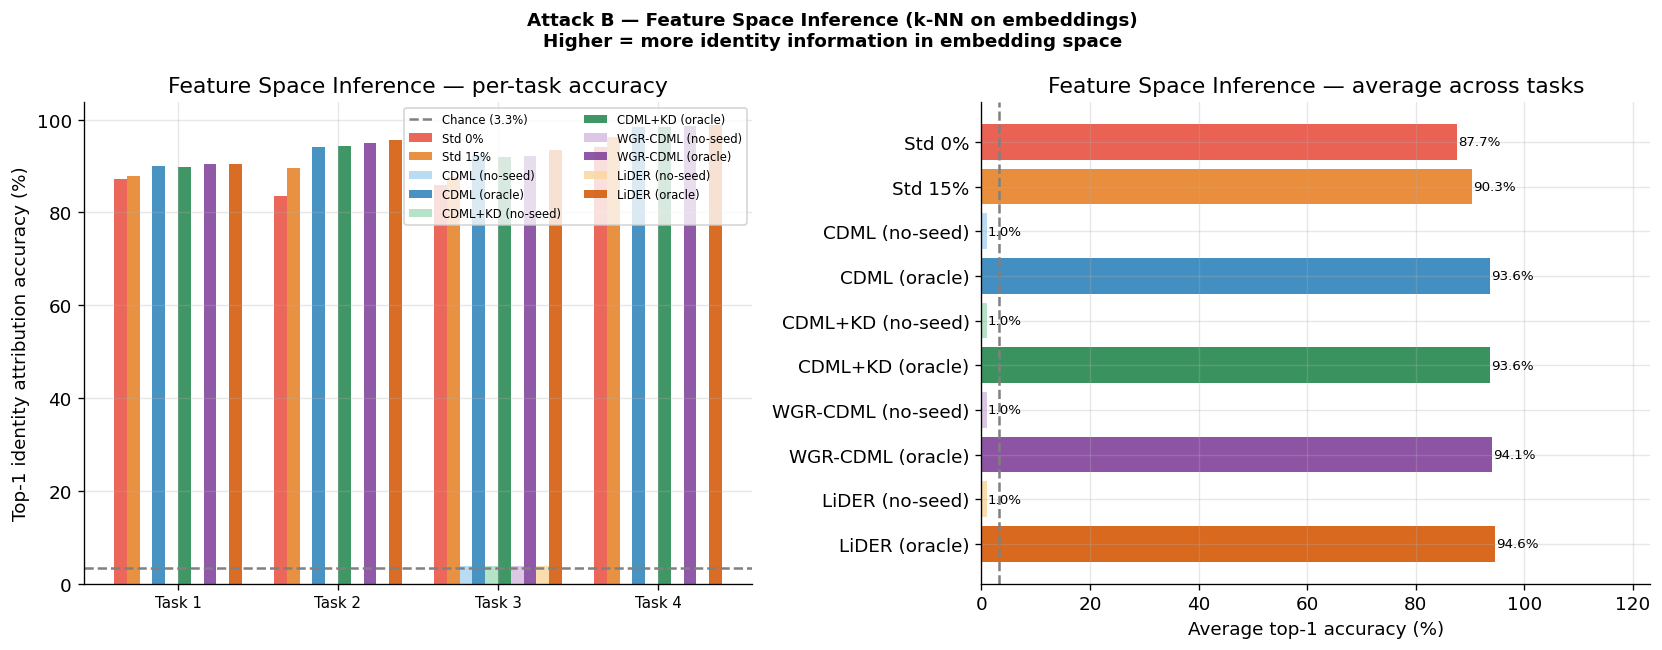

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

probe_colors = {
    'Std 0%':             '#E74C3C', 'Std 15%':              '#E67E22',
    'CDML (no-seed)':     '#AED6F1', 'CDML (oracle)':        '#2980B9',
    'CDML+KD (no-seed)':  '#A9DFBF', 'CDML+KD (oracle)':     '#1E8449',
    'WGR-CDML (no-seed)': '#D7BDE2', 'WGR-CDML (oracle)':    '#7D3C98',
    'LiDER (no-seed)':    '#FAD7A0', 'LiDER (oracle)':       '#D35400',
}

# Per-task top-1 accuracy
ax = axes[0]
x = np.arange(n_tasks); w = 0.08
for i, (key, res) in enumerate(probe_results.items()):
    vals = [res[t]['top1_acc']*100 for t in task_names]
    offset = (i - len(probe_results)/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=key,
           color=probe_colors.get(key, '#888'), alpha=0.85)
ax.axhline(chance*100, color='gray', ls='--', lw=1.5, label=f'Chance ({chance*100:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(task_names, fontsize=9)
ax.set_ylabel('Top-1 identity attribution accuracy (%)')
ax.set_title('Feature Space Inference — per-task accuracy')
ax.legend(fontsize=7, ncol=2)

# Average accuracy comparison
ax2 = axes[1]
keys2    = list(probe_results.keys())
avg_accs = [np.mean([probe_results[k][t]['top1_acc']*100 for t in task_names]) for k in keys2]
bar_cols = [probe_colors.get(k,'#888') for k in keys2]
bars = ax2.barh(keys2[::-1], avg_accs[::-1], color=bar_cols[::-1], alpha=0.88)
ax2.axvline(chance*100, color='gray', ls='--', lw=1.5)
for bar in bars:
    ax2.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=8)
ax2.set_xlabel('Average top-1 accuracy (%)')
ax2.set_title('Feature Space Inference — average across tasks')
ax2.set_xlim(0, max(avg_accs)*1.25 + 5)

plt.suptitle('Attack B — Feature Space Inference (k-NN on embeddings)\n'
             'Higher = more identity information in embedding space',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_probe.png', bbox_inches='tight')
plt.show()

---
## Attack C — Backdoor / Trojan Attack

**Goal:** Inject a sinusoidal trigger during Task 3 training, then test whether an attacker holding any gait device can force the system to authenticate as a specific target subject.

**Design choices (from Phase 7 bug-fixes):**
- Target class = 90 (Task 4 subject — always trained last, never forgotten)
- Trigger amplitude = 0.5σ (0.1 was too weak vs normalised signals)
- Trigger channel = acc_z (channel 2)
- 15% poison fraction of Task 3 data

**Metrics:** Attack Success Rate (ASR) = fraction of trigger-injected test samples predicted as target. Clean accuracy = unchanged model behaviour on clean inputs.

Building poisoned Task 3 dataset...
  Task 3 poisoned: 5559 clean + 981 poisoned → target class 90

Trigger visualisation:


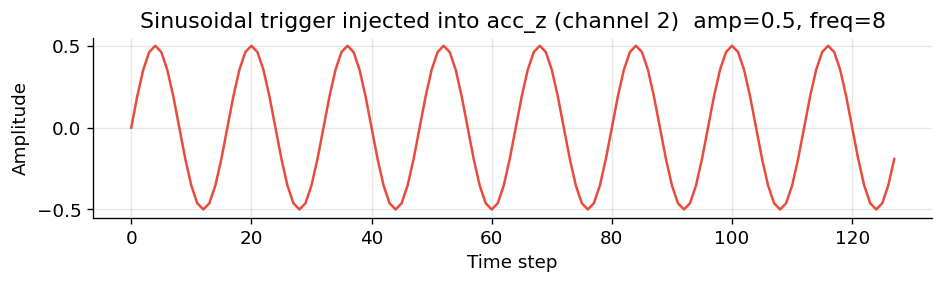

In [20]:
# ── Trigger definition ────────────────────────────────────────────────────────
TRIGGER = (BACKDOOR_TRIGGER_AMP * np.sin(
    2 * np.pi * BACKDOOR_TRIGGER_FREQ *
    np.arange(WINDOW_SIZE, dtype=np.float32) / WINDOW_SIZE)).astype(np.float32)

def inject_trigger(X, ch=BACKDOOR_TRIGGER_CH):
    """Add sinusoidal trigger to channel `ch`. Works on numpy and torch."""
    if isinstance(X, torch.Tensor):
        X = X.clone()
        X[..., ch, :] += torch.tensor(TRIGGER, device=X.device)
    else:
        X = X.copy()
        X[..., ch, :] += TRIGGER
    return X


def build_poisoned_task3(task_data, poison_frac, target_idx):
    train_ds  = task_data['Task 3']['train']
    n         = len(train_ds)
    n_poison  = max(1, int(n * poison_frac))
    all_X     = torch.stack([train_ds[i][0] for i in range(n)])
    all_y     = torch.stack([train_ds[i][1] for i in range(n)])
    rng       = np.random.default_rng(RANDOM_SEED + 999)
    p_idx     = rng.choice(n, n_poison, replace=False)
    c_idx     = np.setdiff1d(np.arange(n), p_idx)
    X_p       = inject_trigger(all_X[p_idx])
    y_p       = torch.full((n_poison,), target_idx, dtype=torch.long)
    print(f'  Task 3 poisoned: {len(c_idx)} clean + {n_poison} poisoned → target class {target_idx}')
    return ConcatDataset([TensorDataset(all_X[c_idx], all_y[c_idx]),
                          TensorDataset(X_p, y_p)])


@torch.no_grad()
def measure_asr(model, task_data, task_names, device, target_idx,
                 is_cdml=False, cdml_final_task='Task 4'):
    """Attack Success Rate: fraction of triggered samples predicted as target."""
    if is_cdml:
        model.set_task_sequence(cdml_final_task, CDML_SEED_BASE + task_names.index(cdml_final_task))
    model.eval()
    total = success = 0
    for task_name in task_names:
        test_ds = task_data[task_name]['test']
        X_all = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
        X_trig = inject_trigger(X_all).to(device)
        preds = model(X_trig).argmax(1)
        success += (preds == target_idx).sum().item()
        total   += len(X_trig)
    return success / total


@torch.no_grad()
def measure_clean_acc(model, task_data, task_names, device, is_cdml=False):
    accs = []
    for t_idx, task_name in enumerate(task_names):
        if is_cdml: model.set_task_sequence(task_name, model.seeds.get(task_name, CDML_SEED_BASE+t_idx))
        tl  = DataLoader(task_data[task_name]['test'], batch_size=256)
        accs.append(evaluate(model, tl, device))
    return np.mean(accs)


print('Building poisoned Task 3 dataset...')
poisoned_t3 = build_poisoned_task3(task_data, BACKDOOR_POISON_FRAC, BACKDOOR_TARGET_IDX)

# Patch task_data to use poisoned Task 3 for backdoored training
task_data_bd = {t: dict(task_data[t]) for t in task_names}
task_data_bd['Task 3']['train'] = poisoned_t3

print('\nTrigger visualisation:')
t_axis = np.arange(WINDOW_SIZE)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t_axis, TRIGGER, color='#E74C3C', lw=1.5)
ax.set_xlabel('Time step'); ax.set_ylabel('Amplitude')
ax.set_title(f'Sinusoidal trigger injected into acc_z (channel {BACKDOOR_TRIGGER_CH})  '
             f'amp={BACKDOOR_TRIGGER_AMP}, freq={BACKDOOR_TRIGGER_FREQ}')
plt.tight_layout()
plt.savefig('fig_trigger.png', bbox_inches='tight')
plt.show()

In [21]:
print('Training backdoored versions of all 6 models on poisoned Task 3...')
backdoor_models = {}
backdoor_accs   = {}

# Std 0%
m, a = train_std(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0, label='Std 0% BD')
backdoor_models['Std 0%'] = m; backdoor_accs['Std 0%'] = a

# Std 15%
m, a = train_std(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=STD_REPLAY_FRAC, label='Std 15% BD')
backdoor_models['Std 15%'] = m; backdoor_accs['Std 15%'] = a

# CDML
m, a = train_cdml(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, label='CDML BD')
backdoor_models['CDML'] = m; backdoor_accs['CDML'] = a

# CDML+KD
m, a = train_cdml_kd(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, label='CDML+KD BD')
backdoor_models['CDML+KD'] = m; backdoor_accs['CDML+KD'] = a

# WGR-CDML
m, a = train_wgr_cdml(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, label='WGR-CDML BD')
backdoor_models['WGR-CDML'] = m; backdoor_accs['WGR-CDML'] = a

# LiDER
m, a = train_lider(task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, label='LiDER BD')
backdoor_models['LiDER'] = m; backdoor_accs['LiDER'] = a

print('All backdoored models trained.')

Training backdoored versions of all 6 models on poisoned Task 3...
[Std 0% BD] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[Std 0% BD] Step 2: Task 2
  Epoch   1/50  val=0.934
  Epoch  25/50  val=0.979
  Epoch  50/50  val=0.982
  → T1:0.3%  T2:93.6%
[Std 0% BD] Step 3: Task 3
  Epoch   1/50  val=0.879
  Epoch  25/50  val=0.962
  Epoch  50/50  val=0.970
  → T1:0.0%  T2:1.4%  T3:92.0%
[Std 0% BD] Step 4: Task 4
  Epoch   1/50  val=0.964
  Epoch  25/50  val=0.981
  Epoch  50/50  val=0.985
  → T1:0.0%  T2:0.1%  T3:2.2%  T4:98.1%
[Std 15% BD] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[Std 15% BD] Step 2: Task 2
  Epoch   1/50  val=0.919
  Epoch  25/50  val=0.969
  Epoch  50/50  val=0.980
  → T1:86.1%  T2:93.8%
[Std 15% BD] Step 3: Task 3
  Epoch   1/50  val=0.909
  Epoch  25/50  val=0.970
  Epoch  50/50  val=0.971
  → T1:85.2%  T2:85.4%  T3:90.7%
[Std 15% BD] Step 4:

Measuring ASR and clean accuracy for all models...
  Std 0%      : ASR= 10.5%  clean_bd= 25.1%  clean_clean= 24.5%
  Std 15%     : ASR= 42.9%  clean_bd= 87.5%  clean_clean= 87.7%
  CDML        : ASR=  3.2%  clean_bd= 70.6%  clean_clean= 73.9%
  CDML+KD     : ASR= 36.1%  clean_bd= 51.1%  clean_clean= 57.1%
  WGR-CDML    : ASR=  2.8%  clean_bd= 74.3%  clean_clean= 74.9%
  LiDER       : ASR= 50.4%  clean_bd= 71.9%  clean_clean= 77.9%


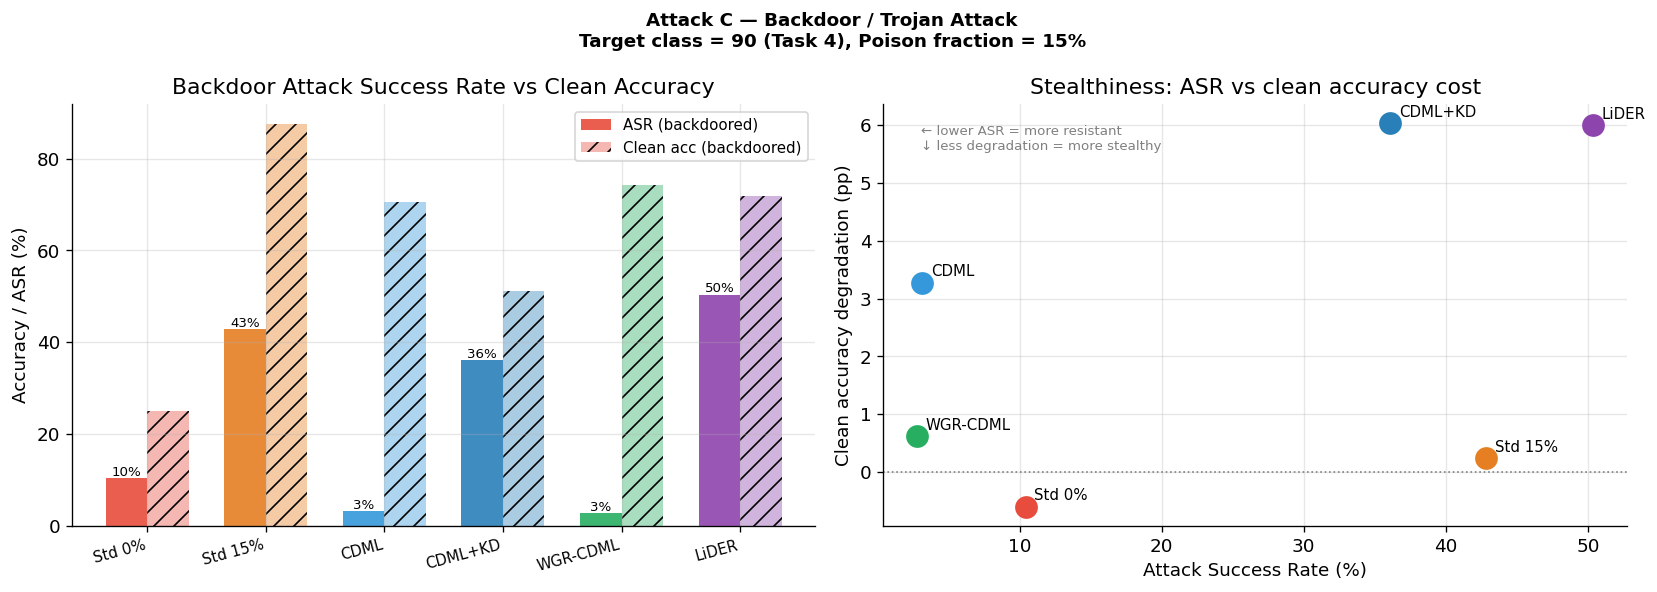

In [23]:
print('Measuring ASR and clean accuracy for all models...')
backdoor_summary = {}

for label, _, is_cdml, color in [(l, m, ic, c) for l,_,_,ic,c in MODEL_REGISTRY]:
    bd_model = backdoor_models[label]
    asr_val  = measure_asr(bd_model, task_data, task_names, DEVICE,
                            BACKDOOR_TARGET_IDX, is_cdml=is_cdml)
    clean_bd = measure_clean_acc(bd_model, task_data, task_names, DEVICE, is_cdml=is_cdml)
    orig_acc_mat = next(mat for l, _, mat, _, _ in MODEL_REGISTRY if l == label)
    clean_orig = np.nanmean(orig_acc_mat[-1, :])
    backdoor_summary[label] = {
        'asr': asr_val, 'clean_bd': clean_bd, 'clean_orig': clean_orig}
    print(f'  {label:<12}: ASR={asr_val*100:5.1f}%  clean_bd={clean_bd*100:5.1f}%  clean_clean={clean_orig*100:5.1f}%')

# ── Backdoor results plot ─────────────────────────────────────────────────────
model_labels = list(backdoor_summary.keys())
asrs         = [backdoor_summary[k]['asr']*100       for k in model_labels]
clean_bds    = [backdoor_summary[k]['clean_bd']*100  for k in model_labels]
clean_origs  = [backdoor_summary[k]['clean_orig']*100 for k in model_labels]
model_colors = {l: c for l,_,_,_,c in MODEL_REGISTRY}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x  = np.arange(len(model_labels))
w  = 0.35
b1 = ax.bar(x - w/2, asrs,      w, label='ASR (backdoored)',
            color=[model_colors[l] for l in model_labels], alpha=0.9)
b2 = ax.bar(x + w/2, clean_bds, w, label='Clean acc (backdoored)',
            color=[model_colors[l] for l in model_labels], alpha=0.4, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(model_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Accuracy / ASR (%)')
ax.set_title('Backdoor Attack Success Rate vs Clean Accuracy')
ax.legend(fontsize=9)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}%', ha='center', fontsize=8)

ax2 = axes[1]
# Scatter: clean accuracy drop (y) vs ASR (x)
for i, lbl in enumerate(model_labels):
    x_val  = asrs[i]
    y_val  = clean_origs[i] - clean_bds[i]   # accuracy degradation
    ax2.scatter(x_val, y_val, color=model_colors[lbl], s=160, zorder=5)
    ax2.annotate(lbl, (x_val, y_val), textcoords='offset points',
                 xytext=(5, 4), fontsize=9)
ax2.set_xlabel('Attack Success Rate (%)')
ax2.set_ylabel('Clean accuracy degradation (pp)')
ax2.set_title('Stealthiness: ASR vs clean accuracy cost')
ax2.axhline(0, color='gray', ls=':', lw=1)
ax2.text(0.05, 0.95, '← lower ASR = more resistant\n↓ less degradation = more stealthy',
         transform=ax2.transAxes, fontsize=8, color='gray', va='top')

plt.suptitle('Attack C — Backdoor / Trojan Attack\n'
             f'Target class = {BACKDOOR_TARGET_IDX} (Task 4), '
             f'Poison fraction = {BACKDOOR_POISON_FRAC*100:.0f}%',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_backdoor.png', bbox_inches='tight')
plt.show()

---
## Final comparison: Accuracy vs Privacy

The key plot for the thesis. Each model is a point in the accuracy–privacy space.
The ideal model is in the **top-left corner**: high accuracy AND high privacy (low attack vulnerability).

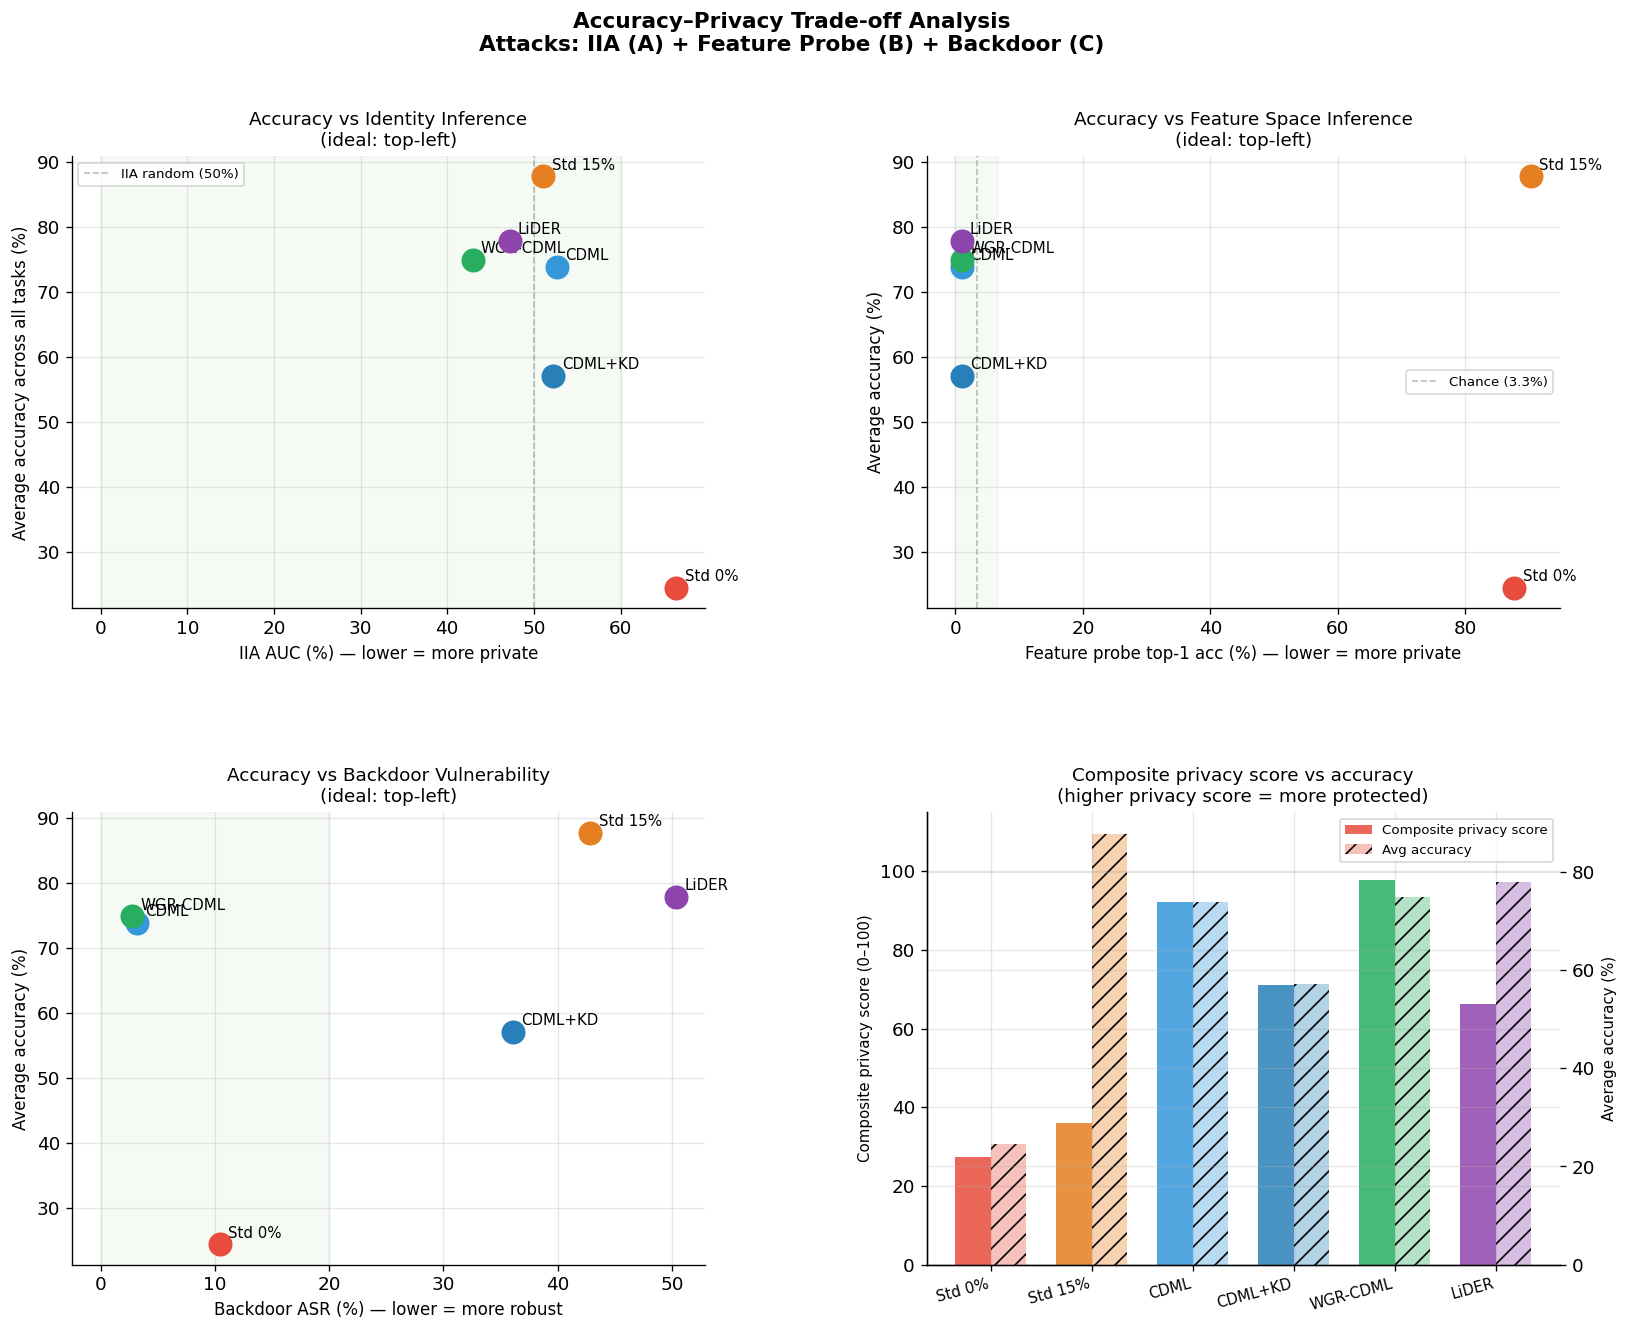

In [24]:
# Compute unified privacy score for each model (no-seed variant for CDML models)
def get_privacy_scores(label, is_cdml):
    """Returns (iia_auc, probe_top1, asr) for the realistic attacker."""
    iia_key   = f'{label} (no-seed)' if is_cdml else label
    probe_key = f'{label} (no-seed)' if is_cdml else label

    iia_auc   = np.mean([iia_results[iia_key][t]['auc']*100
                         for t in task_names]) if iia_key in iia_results else 50.0
    probe_acc = np.mean([probe_results[probe_key][t]['top1_acc']*100
                         for t in task_names]) if probe_key in probe_results else 0.0
    asr       = backdoor_summary[label]['asr'] * 100
    return iia_auc, probe_acc, asr


# ── Main scatter: avg accuracy vs avg IIA AUC ─────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

scatter_data = []
for label, _, acc_mat, is_cdml, color in MODEL_REGISTRY:
    avg_acc = np.nanmean(acc_mat[-1, :]) * 100
    iia_auc, probe_acc, asr = get_privacy_scores(label, is_cdml)
    scatter_data.append((label, avg_acc, iia_auc, probe_acc, asr, color))

# Panel 1: Accuracy vs IIA AUC
ax1 = fig.add_subplot(gs[0, 0])
for label, avg_acc, iia_auc, _, _, color in scatter_data:
    ax1.scatter(iia_auc, avg_acc, color=color, s=180, zorder=5)
    ax1.annotate(label, (iia_auc, avg_acc), textcoords='offset points',
                  xytext=(5,4), fontsize=9)
ax1.axvline(50, color='gray', ls='--', lw=1, alpha=0.5, label='IIA random (50%)')
ax1.set_xlabel('IIA AUC (%) — lower = more private', fontsize=10)
ax1.set_ylabel('Average accuracy across all tasks (%)', fontsize=10)
ax1.set_title('Accuracy vs Identity Inference\n(ideal: top-left)', fontsize=11)
ax1.legend(fontsize=8)
# Shade ideal region
ax1.axvspan(0, 60, alpha=0.04, color='green')

# Panel 2: Accuracy vs Feature Probe top-1
ax2 = fig.add_subplot(gs[0, 1])
for label, avg_acc, _, probe_acc, _, color in scatter_data:
    ax2.scatter(probe_acc, avg_acc, color=color, s=180, zorder=5)
    ax2.annotate(label, (probe_acc, avg_acc), textcoords='offset points',
                  xytext=(5,4), fontsize=9)
ax2.axvline(chance*100, color='gray', ls='--', lw=1, alpha=0.5,
             label=f'Chance ({chance*100:.1f}%)')
ax2.set_xlabel('Feature probe top-1 acc (%) — lower = more private', fontsize=10)
ax2.set_ylabel('Average accuracy (%)', fontsize=10)
ax2.set_title('Accuracy vs Feature Space Inference\n(ideal: top-left)', fontsize=11)
ax2.legend(fontsize=8)
ax2.axvspan(0, chance*100*2, alpha=0.04, color='green')

# Panel 3: Accuracy vs Backdoor ASR
ax3 = fig.add_subplot(gs[1, 0])
for label, avg_acc, _, _, asr, color in scatter_data:
    ax3.scatter(asr, avg_acc, color=color, s=180, zorder=5)
    ax3.annotate(label, (asr, avg_acc), textcoords='offset points',
                  xytext=(5,4), fontsize=9)
ax3.set_xlabel('Backdoor ASR (%) — lower = more robust', fontsize=10)
ax3.set_ylabel('Average accuracy (%)', fontsize=10)
ax3.set_title('Accuracy vs Backdoor Vulnerability\n(ideal: top-left)', fontsize=11)
ax3.axvspan(0, 20, alpha=0.04, color='green')

# Panel 4: Radar / composite privacy score bar
ax4 = fig.add_subplot(gs[1, 1])
# Composite privacy score: normalise each attack so 0=worst, 100=best
iia_aucs   = [d[2]    for d in scatter_data]
probe_accs = [d[3]    for d in scatter_data]
asrs       = [d[4]    for d in scatter_data]

def norm_invert(vals, worst, best):
    """Normalise: worst→0, best→100."""
    r = np.array([(worst-v)/(worst-best+1e-8)*100 for v in vals])
    return np.clip(r, 0, 100)

iia_score_norm   = norm_invert(iia_aucs,   max(iia_aucs),   50.0)
probe_score_norm = norm_invert(probe_accs, max(probe_accs),  0.0)
asr_score_norm   = norm_invert(asrs,       max(asrs),         0.0)
composite        = (iia_score_norm + probe_score_norm + asr_score_norm) / 3
avg_accs         = [d[1] for d in scatter_data]

labels4 = [d[0] for d in scatter_data]
colors4 = [d[5] for d in scatter_data]
ax4_twin = ax4.twinx()
x4 = np.arange(len(labels4))
w4 = 0.35
ax4.bar(x4 - w4/2, composite, w4, color=colors4, alpha=0.85, label='Composite privacy score')
ax4_twin.bar(x4 + w4/2, avg_accs, w4, color=colors4, alpha=0.35, hatch='//', label='Avg accuracy')
ax4.set_xticks(x4); ax4.set_xticklabels(labels4, rotation=15, ha='right', fontsize=9)
ax4.set_ylabel('Composite privacy score (0–100)', fontsize=9)
ax4_twin.set_ylabel('Average accuracy (%)', fontsize=9)
ax4.set_title('Composite privacy score vs accuracy\n(higher privacy score = more protected)', fontsize=11)
ax4.set_ylim(0, 115)
lines1, labs1 = ax4.get_legend_handles_labels()
lines2, labs2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, labs1+labs2, fontsize=8)

fig.suptitle('Accuracy–Privacy Trade-off Analysis\n'
             'Attacks: IIA (A) + Feature Probe (B) + Backdoor (C)',
             fontsize=13, fontweight='bold')
plt.savefig('fig_accuracy_privacy_tradeoff.png', bbox_inches='tight')
plt.show()

In [26]:
print('=' * 72)
print('UNIFIED SECURITY EVALUATION — COMPLETE SUMMARY')
print('=' * 72)

# Accuracy
print(f'\n{"━"*72}')
print('CONTINUAL LEARNING ACCURACY (after Task 4)')
print(f'{"Model":<14} {"T1":>7} {"T2":>7} {"T3":>7} {"T4":>7}  {"Avg":>7}  {"T1 drop":>9}')
print('─' * 60)
for label, _, mat, *_ in MODEL_REGISTRY:
    t1_init = mat[0,0]*100 if not np.isnan(mat[0,0]) else 0
    t1_final= mat[-1,0]*100 if not np.isnan(mat[-1,0]) else 0
    vals    = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg     = np.nanmean(mat[-1,:]) * 100
    drop    = t1_init - t1_final
    print(f'{label:<14}' + ''.join([f' {v:>6.1f}%' for v in vals]) + f'  {avg:>6.1f}%  {drop:>8.1f}pp')

# Attack A: IIA
print(f'\n{"━"*72}')
print('ATTACK A — IIA: Average AUC (realistic attacker, no-seed for CDML)')
print(f'{"Model":<14} {"T1":>10} {"T2":>10} {"T3":>10} {"T4":>10}  {"Avg":>8}  {"Protected?":>12}')
print('─' * 70)
for label, _, _, is_cdml, _ in MODEL_REGISTRY:
    key  = f'{label} (no-seed)' if is_cdml else label
    if key not in iia_results: continue
    aucs = [iia_results[key][t]['auc']*100 for t in task_names]
    avg  = np.mean(aucs)
    prot = '✓ YES' if avg < 60 else ('~ PARTIAL' if avg < 70 else '✗ NO')
    print(f'{label:<14}' + ''.join([f' {a:>9.1f}%' for a in aucs]) + f'  {avg:>7.1f}%  {prot:>12}')

# Attack B: Feature Probe
print(f'\n{"━"*72}')
print(f'ATTACK B — Feature Probe: Average top-1 accuracy (chance = {chance*100:.1f}%)')
print(f'{"Model":<14} {"T1":>10} {"T2":>10} {"T3":>10} {"T4":>10}  {"Avg":>8}  {"Protected?":>12}')
print('─' * 70)
for label, _, _, is_cdml, _ in MODEL_REGISTRY:
    key  = f'{label} (no-seed)' if is_cdml else label
    if key not in probe_results: continue
    accs = [probe_results[key][t]['top1_acc']*100 for t in task_names]
    avg  = np.mean(accs)
    prot = '✓ YES' if avg < chance*100*3 else '✗ NO'
    print(f'{label:<14}' + ''.join([f' {a:>9.1f}%' for a in accs]) + f'  {avg:>7.1f}%  {prot:>12}')

# Attack C: Backdoor
print(f'\n{"━"*72}')
print('ATTACK C — Backdoor: ASR and clean accuracy')
print(f'{"Model":<14} {"ASR":>8} {"Clean (BD)":>12} {"Clean (orig)":>14}  {"Acc drop":>10}  {"Stealthy?":>11}')
print('─' * 70)
for label in [l for l,_,_,_,_ in MODEL_REGISTRY]:
    d    = backdoor_summary[label]
    drop = (d['clean_orig'] - d['clean_bd']) * 100
    stealthy = '✓ YES' if drop < 3.0 else '✗ NO'
    print(f'{label:<14} {d["asr"]*100:>7.1f}% {d["clean_bd"]*100:>11.1f}% {d["clean_orig"]*100:>13.1f}%  {drop:>9.1f}pp  {stealthy:>11}')

# Composite
print(f'\n{"━"*72}')
print('COMPOSITE RANKING: Accuracy × Privacy (higher composite score = better trade-off)')
print(f'{"Model":<14} {"Avg acc":>9} {"Privacy score":>15} {"Composite":>12}')
print('─' * 55)
composite_ranking = sorted(
    zip([d[0] for d in scatter_data],
        avg_accs,
        composite),
    key=lambda x: x[1]*0.5 + x[2]*0.5, reverse=True
)
for rank, (label, acc, priv) in enumerate(composite_ranking, 1):
    combined = acc * 0.5 + priv * 0.5
    print(f'{rank}. {label:<12} {acc:>8.1f}%  {priv:>14.1f}/100  {combined:>11.1f}')
print()
print('Note: composite = 50% accuracy + 50% privacy (equal weighting).')
print('Adjust weighting to reflect your application\'s threat model.')

UNIFIED SECURITY EVALUATION — COMPLETE SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONTINUAL LEARNING ACCURACY (after Task 4)
Model               T1      T2      T3      T4      Avg    T1 drop
────────────────────────────────────────────────────────────
Std 0%            0.0%    0.0%    0.0%   98.0%    24.5%      89.7pp
Std 15%          85.9%   82.3%   85.3%   97.3%    87.7%       3.8pp
CDML             51.0%   75.2%   71.5%   97.9%    73.9%      38.8pp
CDML+KD          52.3%   41.3%   40.4%   94.5%    57.1%      37.4pp
WGR-CDML         52.0%   65.9%   83.2%   98.4%    74.9%      37.7pp
LiDER            56.5%   70.6%   86.1%   98.3%    77.9%      33.2pp

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ATTACK A — IIA: Average AUC (realistic attacker, no-seed for CDML)
Model                  T1         T2         T3         T4       Avg    Protected?
──────────────────────────────────────────────────────────────────────
Std 0